In [59]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax

from probjax.core.stochastic_inverses.inverse_factorys import inverse_matrix_vector_multiplication
from probjax.distributions import MultivariateNormal

from sbi.analysis import pairplot

In [151]:
x_dim = 10
theta_dim = 3

prior = MultivariateNormal(jnp.zeros(theta_dim), jnp.eye(theta_dim))
A = jrandom.normal(jrandom.PRNGKey(0), (x_dim,theta_dim))
likelihood_cov = jnp.eye(x_dim)*0.1

def simulator(key, theta):
    x_o = A @ theta
    eps = jnp.linalg.cholesky(likelihood_cov)@jrandom.normal(key, (x_dim,))
    return x_o + eps


In [152]:
def conjugate_posterior(prior_mean, prior_cov, observations, obs_cov, A):
    # Compute posterior parameters
    precision_prior = jnp.linalg.inv(prior_cov)
    precision_obs = jnp.linalg.inv(obs_cov)
    precision_post = precision_prior + A.T @ precision_obs @ A
    covariance_post = jnp.linalg.inv(precision_post)
    mean_diff = observations - A @ prior_mean
    mean_post = prior_mean + covariance_post @ A.T @ precision_obs @ mean_diff
    
    return mean_post, covariance_post


In [153]:
theta_o = jrandom.normal(jrandom.PRNGKey(42), (theta_dim,))
x_o = simulator(jrandom.PRNGKey(43), theta_o)
x_o

Array([ 0.25587463, -2.7960684 , -0.40022376,  1.4381261 , -1.711268  ,
       -2.1027524 ,  2.829507  ,  0.81899744,  2.1013913 ,  1.7933743 ],      dtype=float32)

In [154]:
post_mean, post_cov = conjugate_posterior(prior.mean, prior.covariance_matrix, x_o, likelihood_cov, A)
posterior = MultivariateNormal(post_mean, post_cov)

In [155]:
def inverse_matrix_vector_multiplication(A):
    eps = jnp.finfo(A.dtype).eps
    m,n = A.shape
    d = min(m,n)
    # SVD
    U, s, V_T = jnp.linalg.svd(A)
    # Filter out very small singular values
    s_inv = jnp.where(s > eps, 1/s, 0)
    is_zero = jnp.concatenate([s < eps, jnp.ones(n - d, dtype=bool)])



    # Orhtogonal basis of the null space
    basis = V_T[is_zero,:]
    # Pseudo inverse
    pseudo_inverse = V_T.T[:,:d] @ (jnp.diag(s_inv) @ U.T[:d,:])


    # Produces an independent sample from the solution space
    def sample_solution(key, b):
        x_star = pseudo_inverse @ b
        noise = basis.T @ jrandom.normal(key, (basis.shape[0],))
        return x_star + noise
    
    return sample_solution

In [156]:
sampling_fn = inverse_matrix_vector_multiplication(A)

def inverse_simulator(key, x):
    key1, key2 = jrandom.split(key, 2)
    noise = jrandom.normal(key1, (x_dim,))*0.4
    x_o = x - noise 
    theta = sampling_fn(key2, x_o)
    return theta

batched_inverse_simulator = jax.vmap(inverse_simulator, in_axes=(0, None), out_axes=0)

In [157]:
thetas = batched_inverse_simulator(jrandom.split(jrandom.PRNGKey(0), 10000), x_o)
thetas_true = posterior.sample(jrandom.PRNGKey(0), (10000,))

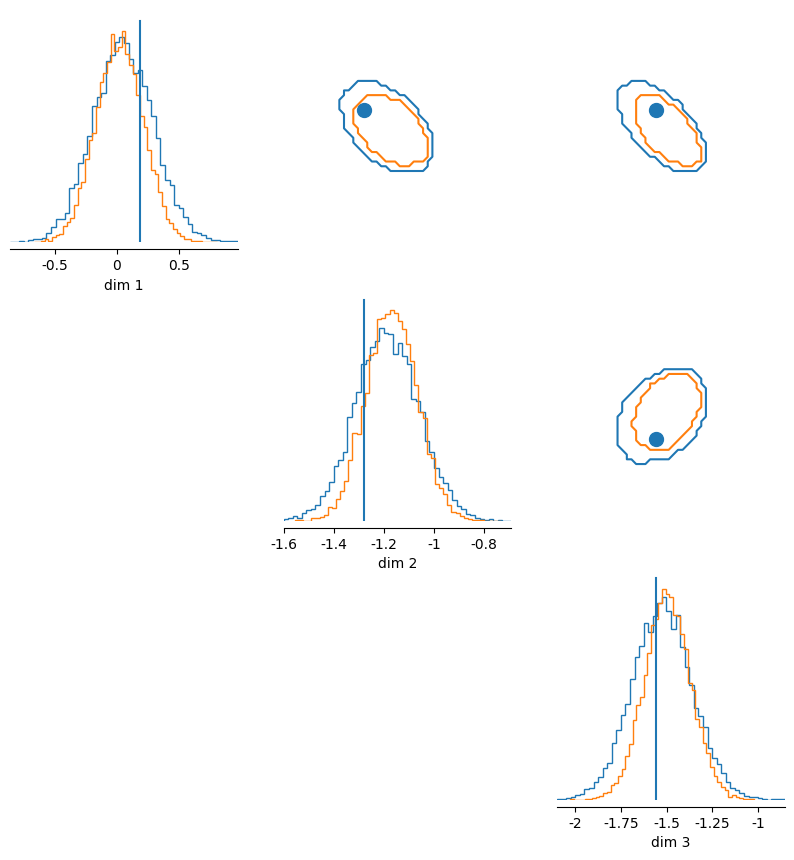

In [158]:
_ = pairplot([np.array(thetas), np.array(thetas_true)], upper="contour", points=np.array(theta_o))